## Machine Learning 1: Predicting Political Stability (Logistic Regression)

Cyber attacks do not occur in a vacuum; they frequently mirror or exacerbate real-world political tensions. We employ **Logistic Regression**, a highly interpretable Supervised Learning algorithm. 

Logistic Regression allows us not only to predict whether a nation's geopolitical environment is **Stable** or **Unstable (High Risk)** based on cyber conflict data, but also to extract the exact positive or negative impact (coefficients) of each feature.

In [15]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import os

# Load the cleaned dataset from previous EDA steps
data_path = '../datasets/processed/processed_cyber_data.csv' 

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("Dataset loaded successfully.")
else:
    print(f"Error: {data_path} not found. Please check your file path.")

print("Preparing and cleaning data for Supervised Political Stability Model...")

# Select relevant features
cols_to_use = ['political_stability', 'weighted_intensity', 'offline_conflict_intensity', 'actor_type', 'motive']
df_pol = df[cols_to_use].copy()

# Convert to numeric (turns unreadable text into NaN)
df_pol['political_stability'] = pd.to_numeric(df_pol['political_stability'], errors='coerce')
df_pol['weighted_intensity'] = pd.to_numeric(df_pol['weighted_intensity'], errors='coerce')


# Fill numeric missing values (using the median)
df_pol['political_stability'] = df_pol['political_stability'].fillna(df_pol['political_stability'].median())
df_pol['weighted_intensity'] = df_pol['weighted_intensity'].fillna(0)

# Fill categorical missing values
categorical_cols = ['offline_conflict_intensity', 'actor_type', 'motive']
for col in categorical_cols:
    # First, fill the missing values with 'Unknown'
    df_pol[col] = df_pol[col].fillna('Unknown')
    # Split by ';' or '/', keep only the first part, and strip whitespaces
    df_pol[col] = df_pol[col].astype(str).apply(lambda x: re.split(r'[;/]', x)[0].strip())

# Categorize the Target Variable (Binary Classification)
# 1 = Unstable (High Risk), 0 = Stable (Low Risk)
median_stability = df_pol['political_stability'].median()
df_pol['Stability_Target'] = np.where(df_pol['political_stability'] < median_stability, 1, 0)

# Feature Engineering: One-Hot Encoding for Categorical Variables
X_numeric = df_pol[['weighted_intensity']]
X_categorical = pd.get_dummies(df_pol[categorical_cols], drop_first=True)

# Combine all features
X_pol = pd.concat([X_numeric, X_categorical], axis=1)
y_pol = df_pol['Stability_Target']

# Train/Test Split (80% Training, 20% Testing)
X_train_pol, X_test_pol, y_train_pol, y_test_pol = train_test_split(X_pol, y_pol, test_size=0.20, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pol)
X_test_scaled = scaler.transform(X_test_pol)

# Initialize and Train the Logistic Regression Model
log_reg = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train_pol)

print("Model training and data cleaning complete.")

Dataset loaded successfully.
Preparing and cleaning data for Supervised Political Stability Model...
Model training and data cleaning complete.


### Evaluation and Political Impact Analysis

With the model trained, we evaluate its predictive accuracy using a Classification Report. More importantly, we extract the **Logistic Regression Coefficients** to visualize the impact of each feature. 

In the resulting chart:
* **Red Bars (Positive Coefficients):** Factors that increase the likelihood of political instability.
* **Blue Bars (Negative Coefficients):** Factors associated with maintaining political stability.

--------------------------------------------------
LOGISTIC REGRESSION ACCURACY: 58.06%
--------------------------------------------------
Detailed Classification Report:

                      precision    recall  f1-score   support

   Stable (Low Risk)       0.58      0.82      0.68      1914
Unstable (High Risk)       0.57      0.29      0.38      1579

            accuracy                           0.58      3493
           macro avg       0.58      0.56      0.53      3493
        weighted avg       0.58      0.58      0.55      3493



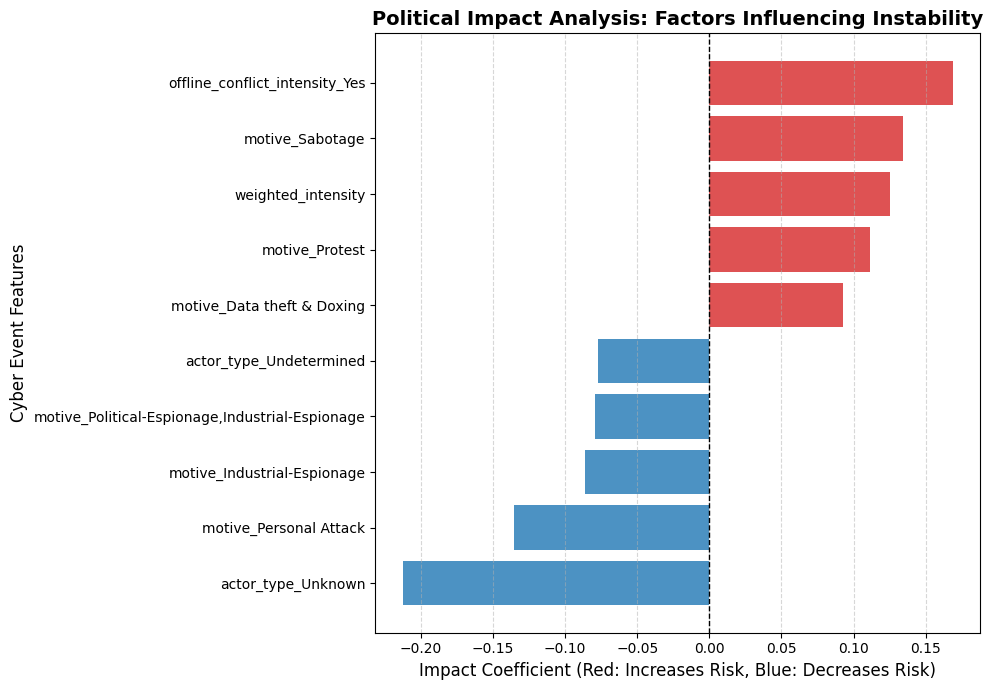

In [16]:
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import os

# Prediction and Evaluation Metrics
y_pred_pol = log_reg.predict(X_test_scaled)
acc_pol = accuracy_score(y_test_pol, y_pred_pol)

print("-" * 50)
print(f"LOGISTIC REGRESSION ACCURACY: {acc_pol:.2%}")
print("-" * 50)

# Map 1 and 0 back to descriptive text for the report
target_names = ['Stable (Low Risk)', 'Unstable (High Risk)']
print("Detailed Classification Report:\n")
print(classification_report(y_test_pol, y_pred_pol, target_names=target_names))

# Visualization: Impact Analysis (Logistic Regression Coefficients)
plt.figure(figsize=(10, 7))

coefficients = log_reg.coef_.flatten() 
feature_names = X_pol.columns.tolist()

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Extract top 5 positive (increase risk) and top 5 negative (decrease risk) impacts
top_positive = coef_df.sort_values(by='Coefficient', ascending=False).head(5)
top_negative = coef_df.sort_values(by='Coefficient', ascending=True).head(5)
top_impacts = pd.concat([top_positive, top_negative]).sort_values(by='Coefficient')

# Define colors: Red for increasing risk (positive coef), Blue for decreasing risk (negative coef)
colors = ['#1f77b4' if c < 0 else '#d62728' for c in top_impacts['Coefficient']]

# Draw the horizontal bar chart
plt.barh(top_impacts['Feature'], top_impacts['Coefficient'], color=colors, alpha=0.8)

# Formatting the plot
plt.title('Political Impact Analysis: Factors Influencing Instability', fontweight='bold', fontsize=14)
plt.xlabel('Impact Coefficient (Red: Increases Risk, Blue: Decreases Risk)', fontsize=12)
plt.ylabel('Cyber Event Features', fontsize=12)
plt.axvline(x=0, color='black', linewidth=1, linestyle='--') # Add a center baseline
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and display
if not os.path.exists('../plots'): 
    os.makedirs('../plots')
plt.savefig('../plots/ml_political_impact_logreg.png', dpi=300)
plt.show()

### Interpretation of Political Stability Model Findings

The Logistic Regression model identifies which cyber factors drive a nation toward **Instability** versus **Stability**.

* **Drivers of Instability (Red Bars):**
    * **Physical Convergence:** Cyber attacks occurring alongside **offline conflicts** are the strongest predictors of political risk.
    * **Direct Disruption:** Motives such as **Sabotage** and **Protest** aim to paralyze infrastructure and amplify civil unrest, directly threatening the political order.
    * **Attack Volume:** A higher **weighted intensity** of cyber incidents naturally correlates with an unstable environment.

* **Indicators of Stability (Blue Bars):**
    * **The Espionage Paradox:** Both **Political and Industrial Espionage** are linked to stable environments. Intelligence operations require a functioning, stable target to remain undetected; chaos would hinder data collection and expose the actors.
    * **Anonymity & Personal Attacks:** Attacks from **Unknown actors** or those targeting **individuals** lack the systemic scale or public "escalation" needed to destabilize a national regime.

**Final Conclusion:**
Cyber warfare acts as a catalyst rather than a sole cause. **Stable nations** are more prone to "silent" espionage, while **unstable nations** are characterized by "loud" sabotage and hybrid warfare (cyber + physical).

## Machine Learning 2: Predicting Attack Motive via Economic Indicators

We now transition to **Predictive Modeling**. The goal is to determine if a country's macroeconomic signature (**GDP per Capita** and **Inflation**) can successfully forecast the **Motive** of a cyber attack.

### Methodology:
* **Model:** Random Forest Classifier.
* **Features (X):** Log-scaled GDP per Capita and Annual Inflation Rate.
* **Target (y):** Primary Attack Motive (Financial, Protest, Political-Espionage).
* **Evaluation:** We use a Confusion Matrix to visualize prediction errors and Feature Importance to identify which economic indicator is a stronger driver of attacker behavior.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import os

# Data Preprocessing: Filter for the top 3 motives to ensure a focused model
target_motives = ['Financial', 'Protest', 'Political-Espionage']
ml_df = df[df['motive'].isin(target_motives)].copy()
ml_df = ml_df.dropna(subset=['gdp_per_capita', 'inflation_cpi', 'motive'])

# Encoding categorical target labels into numerical values
le = LabelEncoder()
y = le.fit_transform(ml_df['motive'])
X = ml_df[['gdp_per_capita', 'inflation_cpi']]

# Splitting data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

## 2. Model Training and Feature Importance

We implement a **Random Forest Classifier**, which is robust against outliers and captures non-linear relationships. After training, we analyze **Feature Importance** to identify whether a nation's wealth (GDP) or economic stability (Inflation) is a stronger driver of cyber-threat behavior.

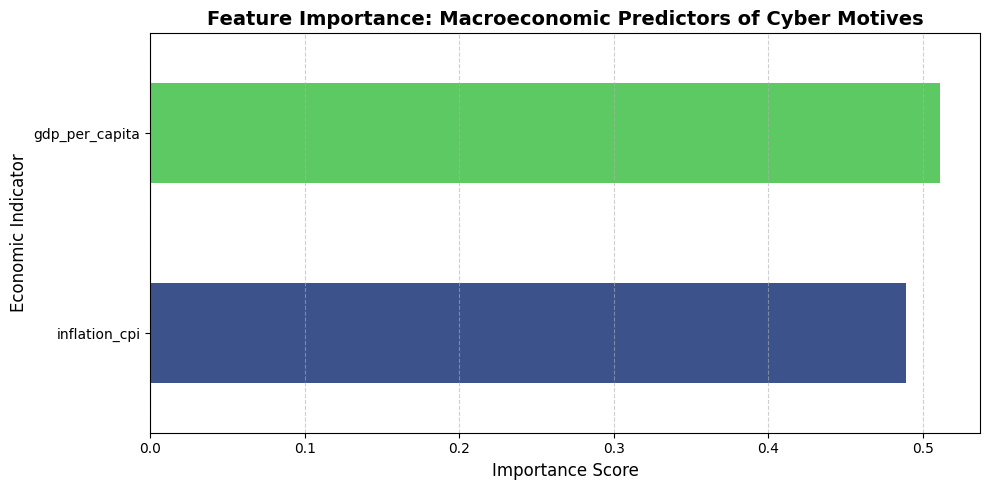

In [18]:
# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Visualization: Feature Importance
plt.figure(figsize=(10, 5))
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color=['#3b528b', '#5dc963'])

plt.title('Feature Importance: Macroeconomic Predictors of Cyber Motives', fontweight='bold', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Economic Indicator', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save and show the plot
if not os.path.exists('../plots'): os.makedirs('../plots')
plt.savefig('../plots/ml_feature_importance.png', dpi=300)
plt.show()

## 3. Performance Evaluation

To assess the model's reliability, we generate a **Classification Report** and a **Confusion Matrix**. These metrics reveal not only the overall accuracy but also which specific motives are most frequently confused by the model based on their economic profiles.

OVERALL MODEL ACCURACY: 86.25%

Detailed Classification Report:
                     precision    recall  f1-score   support

          Financial       0.88      0.97      0.92      1796
Political-Espionage       0.62      0.22      0.33       154
            Protest       0.80      0.61      0.69       399

           accuracy                           0.86      2349
          macro avg       0.76      0.60      0.65      2349
       weighted avg       0.85      0.86      0.85      2349



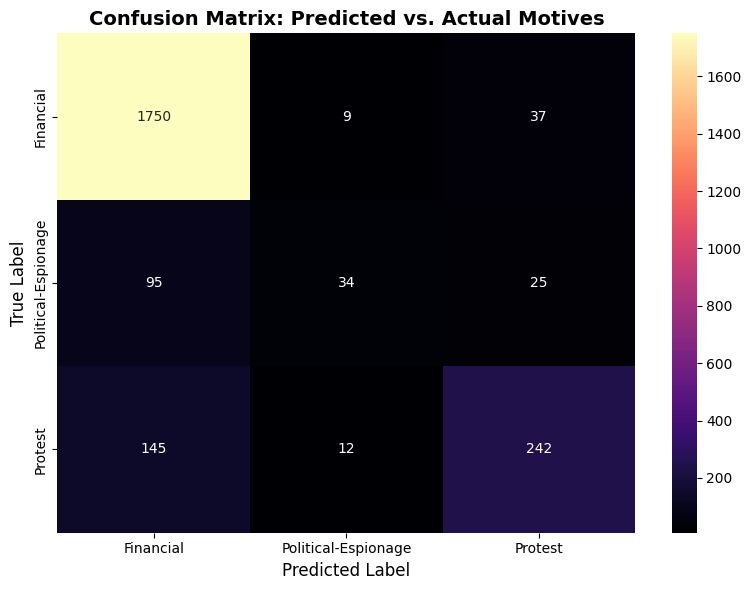

In [19]:
# Make predictions and calculate accuracy
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"OVERALL MODEL ACCURACY: {accuracy:.2%}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Visualization: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', 
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title('Confusion Matrix: Predicted vs. Actual Motives', fontweight='bold', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/ml_confusion_matrix.png', dpi=300)
plt.show()

### Interpretation of Classification Results: Cyber Attack Motives

The Random Forest Classifier achieved a strong overall accuracy of **86.25%**, proving that a country's macroeconomic profile is a reliable predictor of cyber attack motives. However, the Confusion Matrix reveals key real-world dynamics:

* **Financial Motives (High Success):** The model excels at predicting financial attacks (97% recall). It successfully learned that national wealth (GDP) and economic fluctuations (Inflation) are the primary magnets for profit-driven cybercrime.

* **Political-Espionage (Logical Limitation):** The model struggled significantly here (22% recall). State-sponsored espionage is driven by military strategy and global geopolitics, which cannot be captured by macroeconomic indicators alone.

* **Protest Motives (Moderate Success):** Predicted reliably (61% recall), indicating that economic distress triggers a mathematically predictable level of hacktivism.

* **Feature Importance:** Both indicators were equally crucial, with GDP per capita (~51%) slightly outweighing Inflation (~49%).

**Conclusion:** Macroeconomics is an excellent predictor of profit-driven cybercrime and hacktivism, but insufficient for predicting advanced, state-sponsored cyber espionage.

## Machine Learning 3: Unsupervised Learning (K-Means Clustering)

We now apply an **Unsupervised Learning** approach to discover natural groupings within our global dataset. Using the **K-Means Clustering** algorithm, we aim to categorize countries into distinct "Cyber Threat Zones" based on their macroeconomic profiles and historical attack frequencies.

### Methodology:
* **Algorithm:** K-Means Clustering ($K=3$)
* **Features:** Log-scaled GDP per Capita, Average Inflation Rate, and Log-scaled Total Attacks.
* **Objective:** To identify structural similarities between targeted nations without predefined labels, creating data-driven risk profiles.

In [20]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Preparing data for K-Means Clustering...")

# Aggregate data to create 'Country Profiles'
# Calculate the mean macroeconomic indicators and total attacks per country
country_profiles = df.groupby('iso3').agg({
    'gdp_per_capita': 'mean',
    'inflation_cpi': 'mean',
    'motive': 'count' # Using the motive count to represent total attacks
}).rename(columns={'motive': 'total_attacks'}).dropna()

# Handle Outliers with Log Transformation
# Log transformation normalizes the extreme values in GDP and attack volumes
country_profiles['log_gdp'] = np.log1p(country_profiles['gdp_per_capita'])
country_profiles['log_attacks'] = np.log1p(country_profiles['total_attacks'])

# Feature Selection & Scaling
# Standardization is required because K-Means is a distance-based algorithm
features = ['log_gdp', 'inflation_cpi', 'log_attacks']
X_cluster = country_profiles[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Apply K-Means Clustering
# We group the countries into 3 distinct clusters (zones)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
country_profiles['Cluster'] = kmeans.fit_predict(X_scaled)

# Rename Clusters for Readability
cluster_labels = {0: 'Zone A', 1: 'Zone B', 2: 'Zone C'}
country_profiles['Threat_Zone'] = country_profiles['Cluster'].map(cluster_labels)

print("Model training complete! Countries are successfully clustered into Threat Zones.")

Preparing data for K-Means Clustering...
Model training complete! Countries are successfully clustered into Threat Zones.


### Evaluating and Visualizing the Cyber Threat Zones

Now that the K-Means algorithm has grouped the countries, we will extract a statistical summary of these clusters to understand their defining characteristics. Finally, we will visualize the distribution using a multidimensional scatter plot.


--- CLUSTER SUMMARY ---
             gdp_per_capita  inflation_cpi  total_attacks  Number_of_Countries
Threat_Zone                                                                   
Zone A             27659.14           3.25           48.0                   70
Zone B              3652.51           5.46            6.0                   74
Zone C              3656.88         138.81           30.0                    3


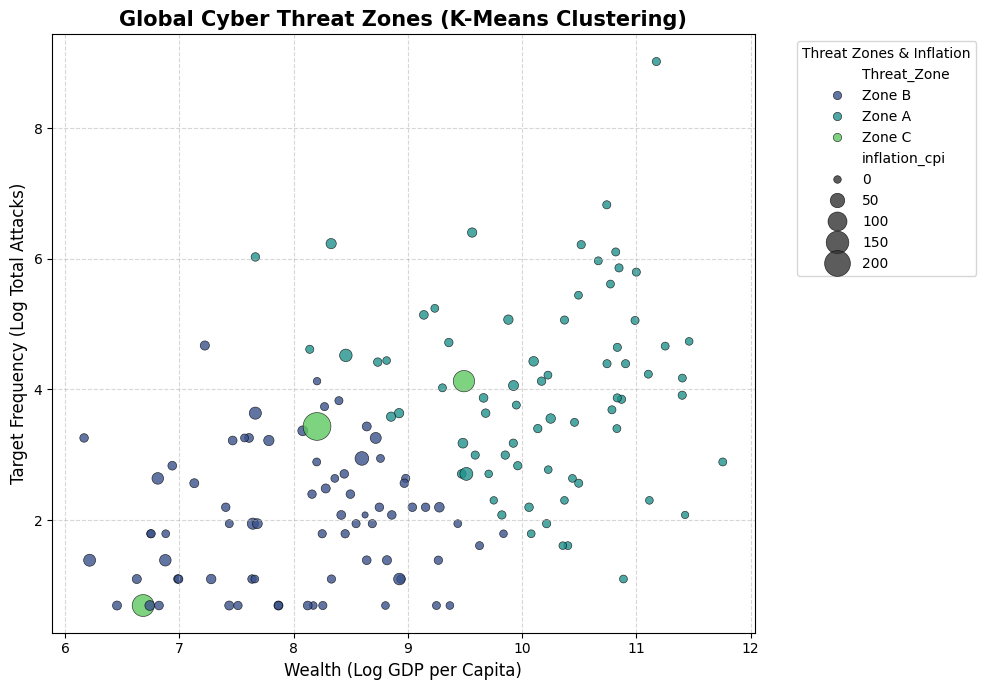

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Extract Statistical Summary of the Clusters
# We use 'median' to avoid the influence of extreme outliers within clusters
cluster_summary = country_profiles.groupby('Threat_Zone').agg({
    'gdp_per_capita': 'median',
    'inflation_cpi': 'median',
    'total_attacks': 'median',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Number_of_Countries'})

print("\n--- CLUSTER SUMMARY ---")
print(cluster_summary.round(2))

# Visualization: Multi-dimensional Scatter Plot
plt.figure(figsize=(10, 7))

# Create the scatter plot:
# X-axis: Wealth, Y-axis: Attacks, Color: Zone, Dot Size: Inflation rate
sns.scatterplot(
    data=country_profiles, 
    x='log_gdp', 
    y='log_attacks', 
    hue='Threat_Zone', 
    palette='viridis', 
    size='inflation_cpi', 
    sizes=(20, 400), 
    alpha=0.8,
    edgecolor='black'
)

# Formatting the plot
plt.title('Global Cyber Threat Zones (K-Means Clustering)', fontweight='bold', fontsize=15)
plt.xlabel('Wealth (Log GDP per Capita)', fontsize=12)
plt.ylabel('Target Frequency (Log Total Attacks)', fontsize=12)

# Adjust legend to be outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Threat Zones & Inflation")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and display the visualization
if not os.path.exists('../plots'): 
    os.makedirs('../plots')
plt.savefig('../plots/ml_kmeans_clusters.png', dpi=300)
plt.show()

### Interpretation of K-Means Clustering: Global Cyber Threat Zones

The Unsupervised Learning model successfully segmented the global landscape into three distinct, highly logical "Threat Zones," revealing a compelling narrative about macroeconomic vulnerability:

* **Zone A (The Lucrative Targets):** Represents 70 wealthy, developed nations (High GDP ~$27.6k, Low Inflation ~3.2%). Despite economic stability, they suffer the highest volume of attacks (Median: 48). This confirms that high digitalization and wealth attract the vast majority of profit-driven cybercrime.

* **Zone B (The Low-Profile Nations):** Represents 74 developing nations (Low GDP ~$3.6k, Moderate Inflation ~5.4%). With less digital infrastructure and lower wealth concentration, they are the least targeted group (Median: 6 attacks).

* **Zone C (The Crisis Zone):** The algorithm isolated a fascinating anomaly of just 3 countries. These nations share the low wealth of Zone B but suffer from severe economic instability (Hyperinflation averaging 138%). Crucially, they experience a significant spike in cyber attacks (Median: 30) compared to their Zone B peers. This insight suggests that periods of severe economic chaos and hyperinflation create critical infrastructural vulnerabilities that threat actors actively exploit.

**Final Conclusion:** By utilizing both Classification and Clustering, it is proved that macroeconomics is a powerful lens for threat intelligence. While GDP dictates the *attractiveness* of a target, sudden inflationary crises expose severe *vulnerabilities*.